# Regresión usando Machine Learning

- 01) Regresión Líneal
- 02) Regresión Líneal Multiple
- 03) Regresión Cuadrática
- 04) Regresión Cúbica
- 05) Regresión Potencial
- 06) Regresión Logarítmica
- 07) Regresión Exponecial
- 08) Regresión Logística
- 09) Regresión Random Forest 
- 10) Regresión mediante SVR (Suport Vector Regression)
- 11) Regresión mediante Serie de Fourier
- 12) DBSCAN

# Aplicación de proceso ML
***80%*** Entranamiento   
***20%*** Prueba y Evalaución   
1. ***Crear datos***
2. ***Crear variables X***, dependientes
3. ***Crear varible objetivo***, target
4. ***Separar train/test***
```
X_train, X_test, y_train, y_test = train_test_split(
    X,
    target,
    test_size=0.2,
    random_state=42
)
```
6. ***Entrenar modelo***
```
modelo = LinearRegression()
modelo.fit(X_train, y_train)
```
8. ***Predecir***   
`y_pred = modelo.predict(X_test)`

10. ***Calcular métricas*** (Evalución del modelo)   
`mae = mean_absolute_error(y_test, y_pred)`   
`mse = mean_squared_error(y_test, y_pred)`   
`rmse = np.sqrt(mse)`   
`r2 = r2_score(y_test, y_pred)`

 
12. ***Graficar***

# Métricas
Para evaluar qué tan bien ajustó la parábola, normalmente se calculan métricas como:

* MAE → Error absoluto medio
* MSE → Error cuadrático medio
* RMSE → Raíz del error cuadrático medio
* R² → Coeficiente de determinación

Las fórmulas son:

MAE
$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|
$$
MSE
$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$
RMSE
$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
$$
R²
$$
R^2 = 1 - \frac{\sum (y_i-\hat{y}_i)^2}{\sum (y_i-\bar{y})^2}
$$

## R²

### Interpretación

0.90 o mas Excelente

0.70 – 0.90 Bueno

0.50 – 0.70 Regular

0.50 o menos Malo


# 1.- LINEAL

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# =====================================================
# DATOS
# =====================================================

x = np.linspace(0,10,100)

ruido = np.random.normal(0,2,100)

y = 2*x + 5 + ruido

# =====================================================
# VARIABLES
# =====================================================

X = x.reshape(-1,1)

# =====================================================
# TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =====================================================
# MODELO
# =====================================================

modelo = LinearRegression()

modelo.fit(X_train,y_train)

# =====================================================
# PREDICCIÓN
# =====================================================

y_pred = modelo.predict(X_test)

# =====================================================
# MÉTRICAS
# =====================================================

print('MAE:',mean_absolute_error(y_test,y_pred))
print('R2:',r2_score(y_test,y_pred))

# =====================================================
# GRÁFICA
# =====================================================

plt.scatter(X_test,y_test,label='Real')

plt.scatter(X_test,y_pred,label='Predicción')

plt.legend()

plt.title('Regresión lineal')

plt.grid()

plt.show()

# 2.- REGRESIÓN MULTIPLE STANDART
Overfitting

MAE  : 14.07
MSE  : 306.35
RMSE : 17.50
R²   : 0.9982


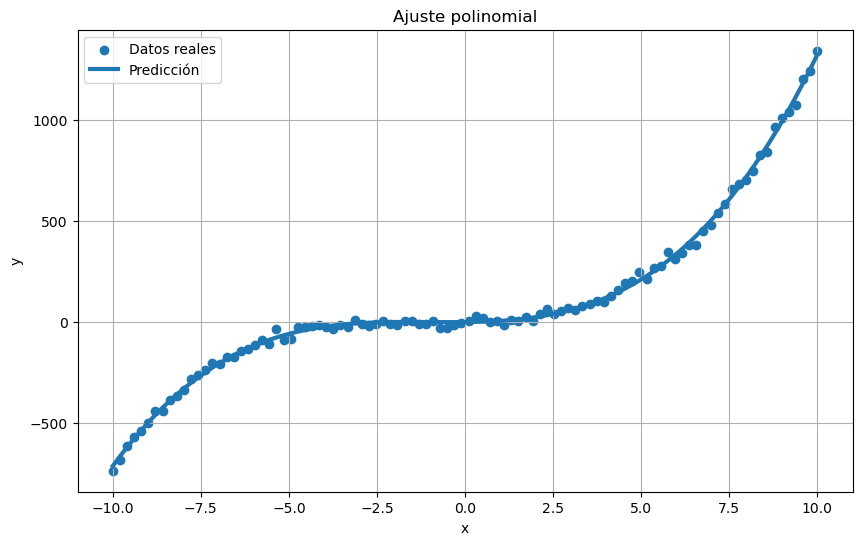

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =====================================================
# 1. DATOS
# =====================================================

x = np.linspace(-10, 10, 100)

# Agregar ruido
ruido = np.random.normal(0, 20, 100)

y = x**3 + 3*x**2 + 2*x - 1 + ruido

# =====================================================
# 2. DATAFRAME
# =====================================================

df = pd.DataFrame({
    'x': x,
    'x2': x**2,
    'x3': x**3,
    'y': y
})

X = df[['x', 'x2','x3']]
target = df['y']

# =====================================================
# 3. ENTRENAMIENTO
# =====================================================

modelo = LinearRegression()

modelo.fit(X, target)

# Predicciones
y_pred = modelo.predict(X)

# =====================================================
# 4. MÉTRICAS
# =====================================================

mae = mean_absolute_error(target, y_pred)

mse = mean_squared_error(target, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(target, y_pred)

# =====================================================
# 5. RESULTADOS
# =====================================================

print(f'MAE  : {mae:.2f}')
print(f'MSE  : {mse:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'R²   : {r2:.4f}')

# =====================================================
# 6. GRÁFICA
# =====================================================

plt.figure(figsize=(10,6))

plt.scatter(x, target, label='Datos reales')

plt.plot(
    x,
    y_pred,
    linewidth=3,
    label='Predicción'
)

plt.title('Ajuste polinomial')

plt.xlabel('x')
plt.ylabel('y')

plt.legend()

plt.grid(True)

plt.show()

# 2.- REGRESIÓN MULTIPLE ML

MAE  : 18.14
MSE  : 487.65
RMSE : 22.08
R²   : 0.9312


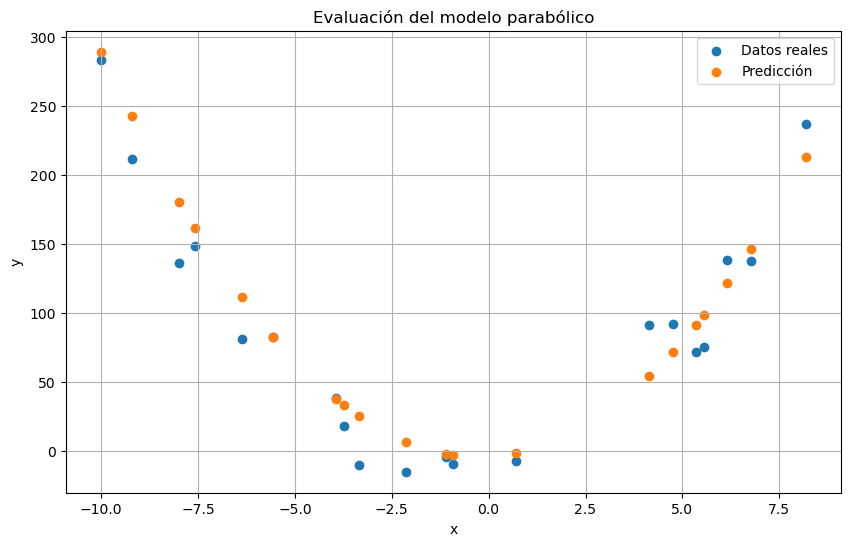

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =====================================================
# 1. CREAR DATOS
# =====================================================

x = np.linspace(-10, 10, 100)

# Ruido aleatorio
ruido = np.random.normal(0, 20, 100)

# Parábola real
y = 3*x**2 + 2*x - 1 + ruido

# =====================================================
# 2. DATAFRAME
# =====================================================

df = pd.DataFrame({
    'x': x,
    'x2': x**2,
    'y': y
})

# Variables predictoras
X = df[['x', 'x2']]

# Variable objetivo
target = df['y']

# =====================================================
# 3. SEPARAR TRAIN Y TEST
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    target,
    test_size=0.2,
    random_state=42
)

# =====================================================
# 4. ENTRENAR MODELO
# =====================================================

modelo = LinearRegression()

modelo.fit(X_train, y_train)

# =====================================================
# 5. PREDICCIONES
# =====================================================

y_pred = modelo.predict(X_test)

# =====================================================
# 6. MÉTRICAS
# =====================================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

# =====================================================
# 7. RESULTADOS
# =====================================================

print(f'MAE  : {mae:.2f}')
print(f'MSE  : {mse:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'R²   : {r2:.4f}')

# =====================================================
# 8. GRÁFICA
# =====================================================

plt.figure(figsize=(10,6))

# Datos reales
plt.scatter(
    X_test['x'],
    y_test,
    label='Datos reales'
)

# Predicción
plt.scatter(
    X_test['x'],
    y_pred,
    label='Predicción'
)

plt.title('Evaluación del modelo parabólico')

plt.xlabel('x')
plt.ylabel('y')

plt.legend()

plt.grid(True)

plt.show()

# 3.- CUADRÁTRICA STANDART

Intercepto: -1.0
Coeficiente x: 2.0
Coeficiente x²: 3.0


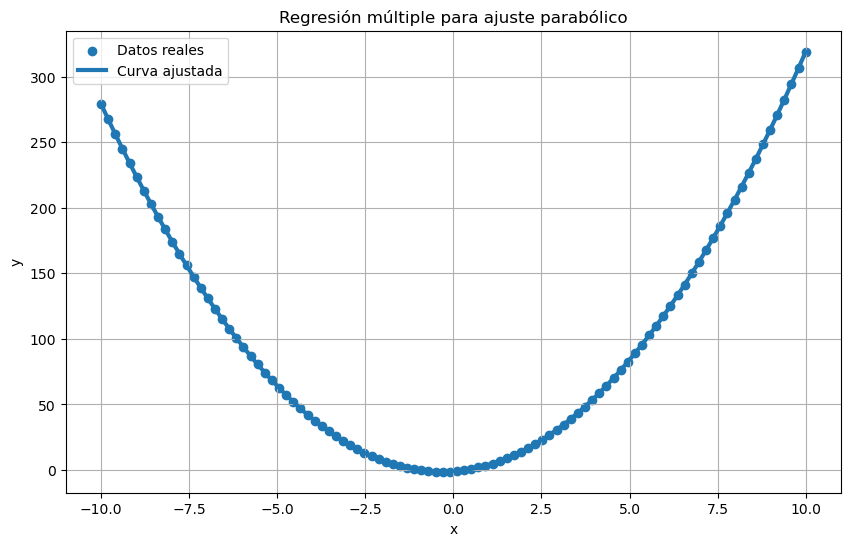

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

# =====================================================
# 1. CREAR DATOS
# =====================================================

x = np.linspace(-10, 10, 100)
ruido = np.random.normal(0, 20, 100)

# Ecuación real
y = 3*x**2 + 2*x - 1 #+ ruido

# =====================================================
# 2. CREAR VARIABLES PARA REGRESIÓN MÚLTIPLE
# =====================================================

df = pd.DataFrame({
    'x': x,
    'x2': x**2,
    'y': y
})

# Variables independientes
X = df[['x', 'x2']]

# Variable dependiente
target = df['y']

# =====================================================
# 3. ENTRENAR MODELO
# =====================================================

modelo = LinearRegression()

modelo.fit(X, target)

# Predicciones
df['y_pred'] = modelo.predict(X)

# =====================================================
# 4. MOSTRAR ECUACIÓN APRENDIDA
# =====================================================

print('Intercepto:', modelo.intercept_)
print('Coeficiente x:', modelo.coef_[0])
print('Coeficiente x²:', modelo.coef_[1])

# =====================================================
# 5. GRÁFICA PRINCIPAL
# =====================================================

plt.figure(figsize=(10,6))

# Datos reales
plt.scatter(
    df['x'],
    df['y'],
    label='Datos reales'
)

# Curva ajustada
plt.plot(
    df['x'],
    df['y_pred'],
    linewidth=3,
    label='Curva ajustada'
)

plt.title('Regresión múltiple para ajuste parabólico')
plt.xlabel('x')
plt.ylabel('y')

plt.legend()

plt.grid(True)

plt.show()

# 3.- CUADRATICA ML

R2: 0.9306006391223899


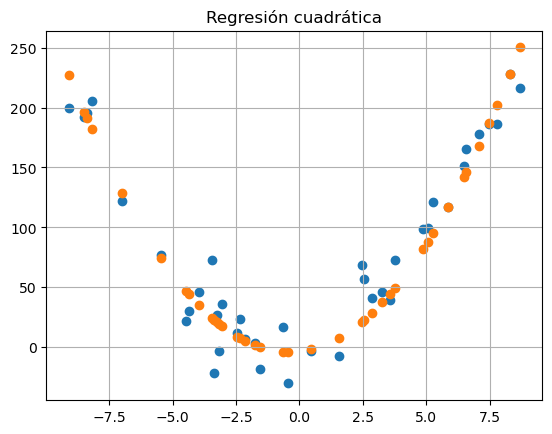

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# =====================================================
# DATOS
# =====================================================

x = np.linspace(-10,10,200)

ruido = np.random.normal(0,20,200)

y = 3*x**2 + 2*x -1 + ruido

# =====================================================
# DATAFRAME
# =====================================================

df = pd.DataFrame({
    'x':x,
    'x2':x**2
})

X = df[['x','x2']]

# =====================================================
# SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =====================================================
# MODELO
# =====================================================

modelo = LinearRegression()

modelo.fit(X_train,y_train)

# =====================================================
# PREDICCIÓN
# =====================================================

y_pred = modelo.predict(X_test)

# =====================================================
# MÉTRICAS
# =====================================================

print('R2:',r2_score(y_test,y_pred))

# =====================================================
# GRÁFICA
# =====================================================

plt.scatter(X_test['x'],y_test)

plt.scatter(X_test['x'],y_pred)

plt.title('Regresión cuadrática')

plt.grid()

plt.show()

# 4.-  CUBICA

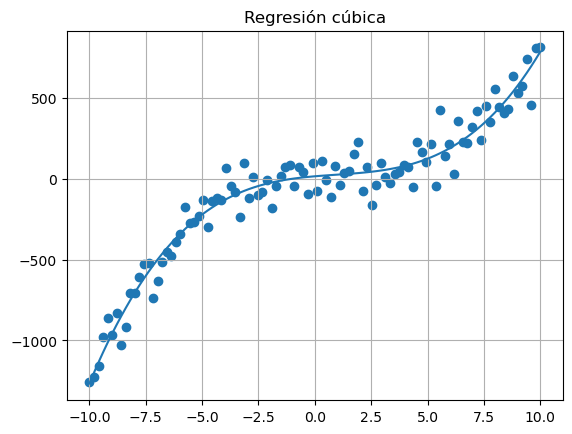

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

x = np.linspace(-10,10,100)
ruido = np.random.normal(0,100,100)

y = x**3 - 2*x**2 + 5*x - 1 + ruido

df = pd.DataFrame({
    'x':x,
    'x2':x**2,
    'x3':x**3
})

X = df[['x','x2','x3']]

modelo = LinearRegression()
modelo.fit(X,y)

y_pred = modelo.predict(X)

plt.scatter(x,y)
plt.plot(x,y_pred)
plt.title('Regresión cúbica')
plt.grid()
plt.show()

# 5.- POTENCIAL

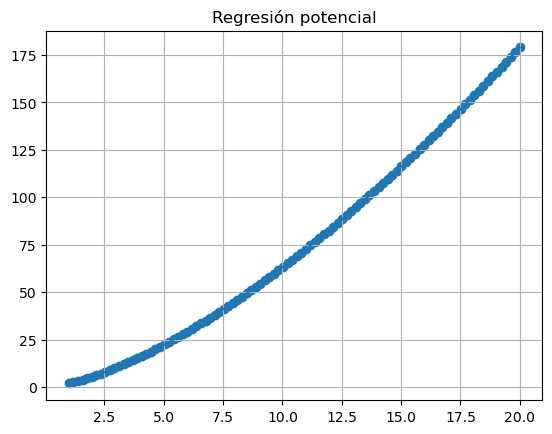

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

x = np.linspace(1,20,100)
y = 2*x**1.5

log_x = np.log(x)
log_y = np.log(y)

X = log_x.reshape(-1,1)

modelo = LinearRegression()
modelo.fit(X,log_y)

log_pred = modelo.predict(X)

y_pred = np.exp(log_pred)

plt.scatter(x,y)
plt.plot(x,y_pred)
plt.title('Regresión potencial')
plt.grid()
plt.show()

# 6.- LOGARITMICA

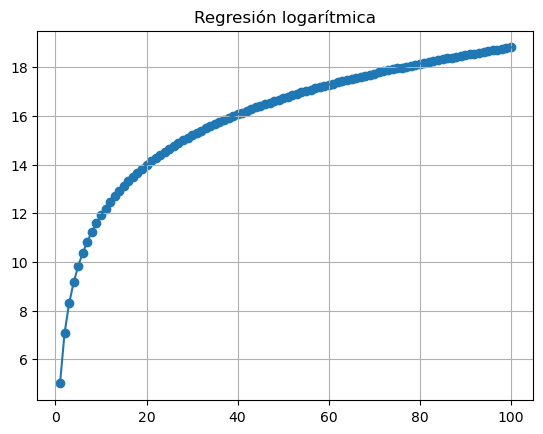

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

x = np.linspace(1,100,100)

y = 5 + 3*np.log(x)

X = np.log(x).reshape(-1,1)

modelo = LinearRegression()
modelo.fit(X,y)

y_pred = modelo.predict(X)

plt.scatter(x,y)
plt.plot(x,y_pred)
plt.title('Regresión logarítmica')
plt.grid()
plt.show()

# 7. EXPONENCIAL

y = a * e^(b*x)

ln(y) = ln(a) + b*x

MAE  : 17.23
MSE  : 462.00
RMSE : 21.49
R²   : 0.8640
a: 0.9757
b: 0.5854
Modelo aproximado: y = 0.9757 * e^(0.5854x)


C:\Users\jtorr\anaconda3\envs\jupyter_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


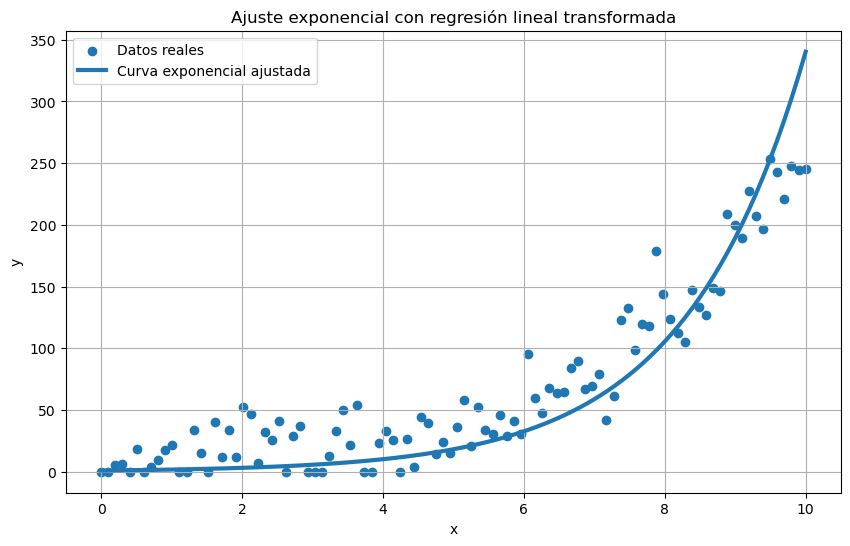

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Crear datos exponenciales
x = np.linspace(0, 10, 100)

ruido = np.random.normal(0, 20, 100)

# Función real exponencial
y = 5 * np.exp(0.4 * x) + ruido

# IMPORTANTE: log(y) solo funciona si y > 0
y = np.where(y <= 0, 0.01, y)

df = pd.DataFrame({
    'x': x,
    'y': y
})

# 2. Transformar y a logaritmo natural
df['log_y'] = np.log(df['y'])

# 3. Variables
X = df[['x']]
target = df['log_y']

# 4. Separar entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    target,
    test_size=0.2,
    random_state=42
)

# 5. Entrenar modelo lineal sobre log(y)
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# 6. Predicción en escala logarítmica
log_y_pred = modelo.predict(X_test)

# 7. Regresar a escala original
y_pred = np.exp(log_y_pred)

# Valores reales en escala original
y_test_real = np.exp(y_test)

# 8. Métricas en escala original
mae = mean_absolute_error(y_test_real, y_pred)
mse = mean_squared_error(y_test_real, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_real, y_pred)

print(f'MAE  : {mae:.2f}')
print(f'MSE  : {mse:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'R²   : {r2:.4f}')

# 9. Coeficientes del modelo exponencial
b = modelo.coef_[0]
a = np.exp(modelo.intercept_)

print(f'a: {a:.4f}')
print(f'b: {b:.4f}')

print(f'Modelo aproximado: y = {a:.4f} * e^({b:.4f}x)')

# 10. Gráfica ordenada
x_linea = np.linspace(df['x'].min(), df['x'].max(), 200).reshape(-1, 1)
y_linea = np.exp(modelo.predict(x_linea))

plt.figure(figsize=(10,6))

plt.scatter(df['x'], df['y'], label='Datos reales')
plt.plot(x_linea, y_linea, linewidth=3, label='Curva exponencial ajustada')

plt.title('Ajuste exponencial con regresión lineal transformada')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

R2: 0.7895765723217781


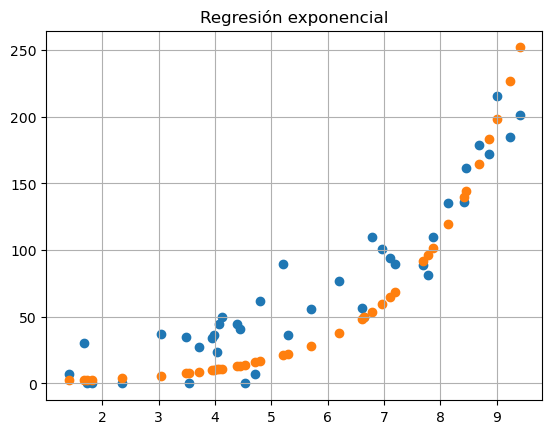

In [15]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# =====================================================
# DATOS
# =====================================================

x = np.linspace(1,10,200)

ruido = np.random.normal(0,20,200)

y = 5*np.exp(0.4*x) + ruido

y = np.where(y<=0,0.01,y)

# =====================================================
# TRANSFORMACIÓN
# =====================================================

log_y = np.log(y)

X = x.reshape(-1,1)

# =====================================================
# SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    log_y,
    test_size=0.2,
    random_state=42
)

# =====================================================
# MODELO
# =====================================================

modelo = LinearRegression()

modelo.fit(X_train,y_train)

# =====================================================
# PREDICCIÓN
# =====================================================

log_pred = modelo.predict(X_test)

y_pred = np.exp(log_pred)

y_real = np.exp(y_test)

# =====================================================
# MÉTRICAS
# =====================================================

print('R2:',r2_score(y_real,y_pred))

# =====================================================
# GRÁFICA
# =====================================================

plt.scatter(X_test,y_real)

plt.scatter(X_test,y_pred)

plt.title('Regresión exponencial')

plt.grid()

plt.show()

# 8. LOGÍSTICA

Accuracy: 1.0


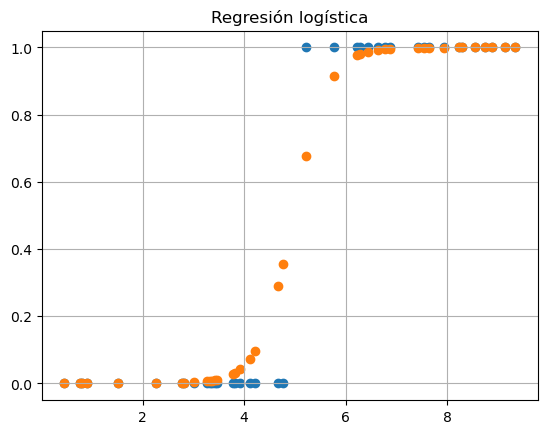

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# =====================================================
# DATOS
# =====================================================

x = np.linspace(0,10,200)

y = (x > 5).astype(int)

X = x.reshape(-1,1)

# =====================================================
# SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =====================================================
# MODELO
# =====================================================

modelo = LogisticRegression()

modelo.fit(X_train,y_train)

# =====================================================
# PREDICCIÓN
# =====================================================

y_pred = modelo.predict(X_test)

# =====================================================
# MÉTRICAS
# =====================================================

print('Accuracy:',accuracy_score(y_test,y_pred))

# =====================================================
# PROBABILIDADES
# =====================================================

prob = modelo.predict_proba(X_test)[:,1]

# =====================================================
# GRÁFICA
# =====================================================

plt.scatter(X_test,y_test)

plt.scatter(X_test,prob)

plt.title('Regresión logística')

plt.grid()

plt.show()

# 9. RANDOM FOREST

R2: 0.9904489183025798


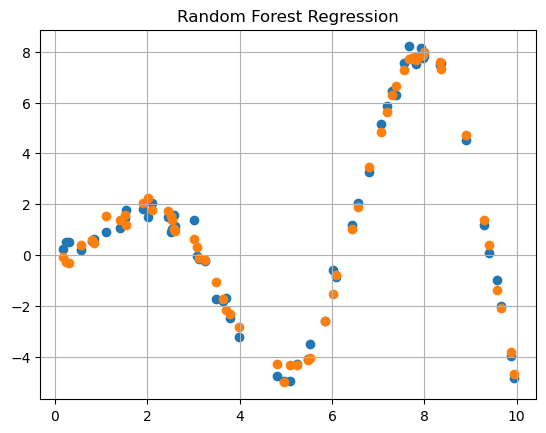

In [19]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# =====================================================
# DATOS
# =====================================================

x = np.linspace(0,10,300)

ruido = np.random.normal(0,0.3,300)

y = x*np.sin(x) + ruido

X = x.reshape(-1,1)

# =====================================================
# SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =====================================================
# MODELO
# =====================================================

modelo = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

modelo.fit(X_train,y_train)

# =====================================================
# PREDICCIÓN
# =====================================================

y_pred = modelo.predict(X_test)

# =====================================================
# MÉTRICAS
# =====================================================

print('R2:',r2_score(y_test,y_pred))

# =====================================================
# GRÁFICA
# =====================================================

plt.scatter(X_test,y_test)

plt.scatter(X_test,y_pred)

plt.title('Random Forest Regression')

plt.grid()

plt.show()

# 10.- SVR

MAE  : 0.2146
MSE  : 0.0699
RMSE : 0.2643
R²   : 0.8381


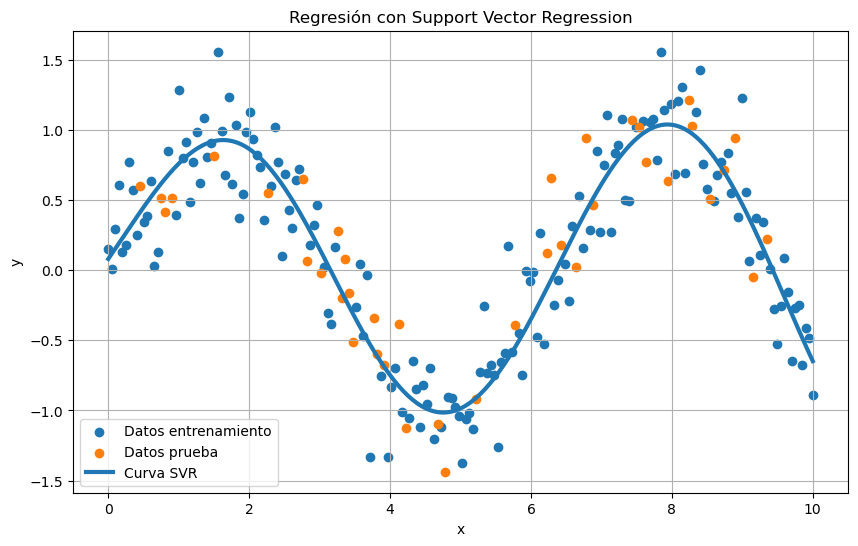

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================================================
# 1. CREAR DATOS
# =====================================================

np.random.seed(42)

x = np.linspace(0, 10, 200)

ruido = np.random.normal(0, 0.3, 200)

# Comportamiento no lineal
y = np.sin(x) + ruido

# =====================================================
# 2. PREPARAR VARIABLES
# =====================================================

X = x.reshape(-1, 1)

# =====================================================
# 3. SEPARAR TRAIN / TEST
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =====================================================
# 4. CREAR Y ENTRENAR MODELO SVR
# =====================================================

modelo = SVR(
    kernel='rbf',
    C=10,
    epsilon=0.1,
    gamma='scale'
)

modelo.fit(X_train, y_train)

# =====================================================
# 5. PREDICCIÓN
# =====================================================

y_pred = modelo.predict(X_test)

# =====================================================
# 6. MÉTRICAS
# =====================================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

# =====================================================
# 7. GRÁFICA
# =====================================================

# Para dibujar una curva suave
x_linea = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_linea = modelo.predict(x_linea)

plt.figure(figsize=(10, 6))

plt.scatter(X_train, y_train, label='Datos entrenamiento')
plt.scatter(X_test, y_test, label='Datos prueba')
plt.plot(x_linea, y_linea, linewidth=3, label='Curva SVR')

plt.title('Regresión con Support Vector Regression')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# 10.- SVR

MAE  : 0.02170
MSE  : 0.00079
RMSE : 0.02818
R²   : 0.95736


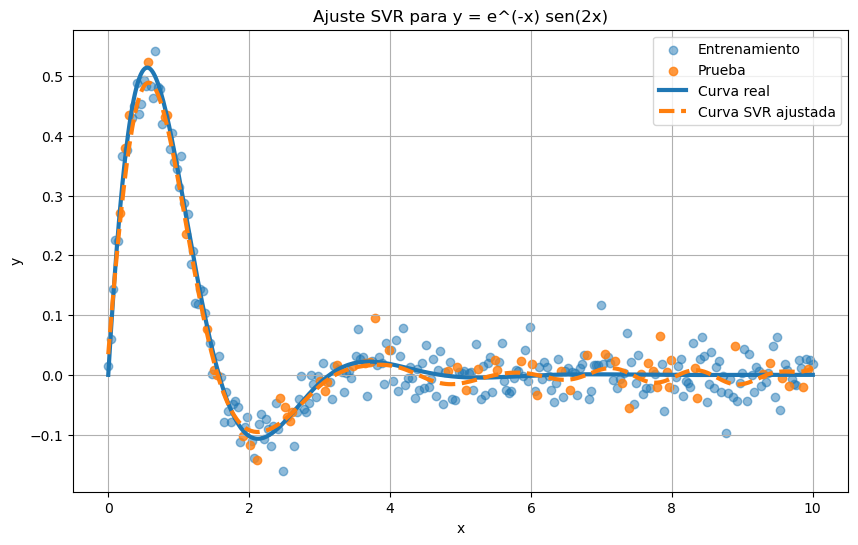

In [39]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================================================
# 1. CREAR DATOS
# =====================================================

np.random.seed(42)

x = np.linspace(0, 10, 300)

# Curva real: e^(-x) * sen(2x)
y = np.exp(-x) * np.sin(2*x)

# Agregar ruido
ruido = np.random.normal(0, 0.03, len(x))
y_ruido = y + ruido

# =====================================================
# 2. PREPARAR VARIABLES
# =====================================================

X = x.reshape(-1, 1)

# =====================================================
# 3. SEPARAR TRAIN / TEST
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_ruido,
    test_size=0.2,
    random_state=42
)

# =====================================================
# 4. ENTRENAR MODELO SVR
# =====================================================

modelo = SVR(
    kernel='rbf',
    C=10,
    epsilon=0.02,
    gamma=1
)

modelo.fit(X_train, y_train)

# =====================================================
# 5. PREDICCIÓN
# =====================================================

y_pred = modelo.predict(X_test)

# =====================================================
# 6. MÉTRICAS
# =====================================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.5f}")
print(f"MSE  : {mse:.5f}")
print(f"RMSE : {rmse:.5f}")
print(f"R²   : {r2:.5f}")

# =====================================================
# 7. CURVA SUAVE PARA GRAFICAR
# =====================================================

x_linea = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)

y_linea_real = np.exp(-x_linea.ravel()) * np.sin(2*x_linea.ravel())

y_linea_pred = modelo.predict(x_linea)

# =====================================================
# 8. GRÁFICA
# =====================================================

plt.figure(figsize=(10,6))

plt.scatter(X_train, y_train, alpha=0.5, label='Entrenamiento')
plt.scatter(X_test, y_test, alpha=0.8, label='Prueba')

plt.plot(
    x_linea,
    y_linea_real,
    linewidth=3,
    label='Curva real'
)

plt.plot(
    x_linea,
    y_linea_pred,
    linewidth=3,
    linestyle='--',
    label='Curva SVR ajustada'
)

plt.title('Ajuste SVR para y = e^(-x) sen(2x)')
plt.xlabel('x')
plt.ylabel('y')

plt.legend()
plt.grid(True)
plt.show()

# 11.- SERIES DE FOURIER

MAE  : 0.01777
MSE  : 0.00058
RMSE : 0.02400
R²   : 0.96856


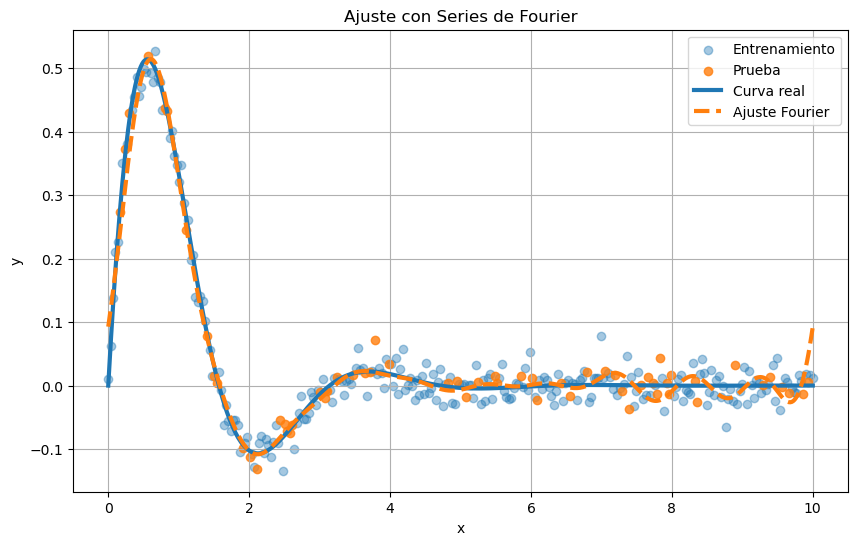

In [41]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================================================
# 1. CREAR DATOS
# =====================================================

np.random.seed(42)

x = np.linspace(0, 10, 300)

y_real = np.exp(-x) * np.sin(2*x)

ruido = np.random.normal(0, 0.02, len(x))

y = y_real + ruido

# =====================================================
# 2. CREAR VARIABLES FOURIER
# =====================================================

def crear_fourier_features(x, n_armonicos, L):
    X_fourier = []

    for n in range(1, n_armonicos + 1):
        X_fourier.append(np.sin(2*np.pi*n*x/L))
        X_fourier.append(np.cos(2*np.pi*n*x/L))

    return np.column_stack(X_fourier)

L = x.max() - x.min()
n_armonicos = 10

X = crear_fourier_features(x, n_armonicos, L)

# =====================================================
# 3. SEPARAR TRAIN / TEST
# =====================================================

X_train, X_test, y_train, y_test, x_train, x_test = train_test_split(
    X,
    y,
    x,
    test_size=0.2,
    random_state=42
)

# =====================================================
# 4. ENTRENAR MODELO
# =====================================================

modelo = LinearRegression()

modelo.fit(X_train, y_train)

# =====================================================
# 5. PREDICCIÓN
# =====================================================

y_pred = modelo.predict(X_test)

# =====================================================
# 6. MÉTRICAS
# =====================================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.5f}")
print(f"MSE  : {mse:.5f}")
print(f"RMSE : {rmse:.5f}")
print(f"R²   : {r2:.5f}")

# =====================================================
# 7. CURVA SUAVE PARA GRAFICAR
# =====================================================

x_linea = np.linspace(0, 10, 500)

X_linea = crear_fourier_features(x_linea, n_armonicos, L)

y_linea_pred = modelo.predict(X_linea)

y_linea_real = np.exp(-x_linea) * np.sin(2*x_linea)

# =====================================================
# 8. GRÁFICA
# =====================================================

plt.figure(figsize=(10,6))

plt.scatter(x_train, y_train, alpha=0.4, label='Entrenamiento')
plt.scatter(x_test, y_test, alpha=0.8, label='Prueba')

plt.plot(
    x_linea,
    y_linea_real,
    linewidth=3,
    label='Curva real'
)

plt.plot(
    x_linea,
    y_linea_pred,
    linestyle='--',
    linewidth=3,
    label='Ajuste Fourier'
)

plt.title('Ajuste con Series de Fourier')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# 12.- DBSCAN

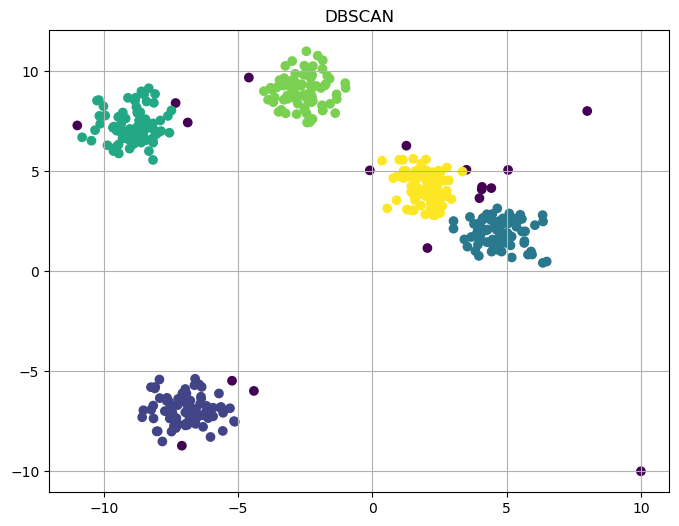

[ 0  1  0  2  1  3  2  2 -1  0 -1  3  3  4  1  4  0  4  3  1  0  3  0  3
  1  4  2  4  0  2  0  4  3  3  4  0  3  1  1  4  3  1  4  2  4  2  2  0
  0  2  2  3  2  3  4 -1  1  4  0  3  1  4 -1 -1  0  0  3  3  4  1  0  2
  1  0 -1  1  1  3  4  0  3  1  1  3  4  2 -1  0  1  2  1  4  1  0  0  0
  0  4  1  4  2 -1  4  2  3  2  2  4  1  4  0  1  3  1  4  2  2  2  0  1
  4  2  3  1  0  2  3  2  0  4  2  3  3  1  0  4  0  1  3  4  3  2  3  4
  2  0  3  1  2  3  2 -1  4  3  2  1  2  3  0  1  1  3  1  3  1  0  1  4
  0  4  2  4  0  3  2  2 -1  1  1  3  1  4  2  1  0  0  2  0  3  3  2  0
  4  1  2  2  1  0  0  0  2  4  4  0  3  2  3  3  1  1  3  4  0  0  3  0
  1  1  0  2  2  1  3  1  2  3  3  2  0  4  3  0  3  0  3  1  1  1  4  4
  4  4  2  1  4  3  3  4  2  3  2  0  1  3  0  0  1  0  2  0  3  0  2  4
  1  0  1 -1  4  0  4  2  3  0  1  0  2  1  1  2  3  1  0  4  3  1  4  4
  3  3  2  4  4  0  1  4  1  1  2  1  3  1  1  4 -1  1  4  0  1  4  0  4
  4  3  1  3  4  0  3  3  2  3  2  2  2  0  2  4  1

In [45]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs

# =====================================================
# CREAR DATOS
# =====================================================

X, _ = make_blobs(
    n_samples=400,
    centers=5,
    cluster_std=0.8,
    random_state=42
)

# Agregar outliers manualmente
outliers = np.array([
    [8,8],
    [-8,-8],
    [10,-10]
])

X = np.vstack([X, outliers])

# =====================================================
# MODELO DBSCAN
# =====================================================

modelo = DBSCAN(
    eps=0.7,
    min_samples=5
)

clusters = modelo.fit_predict(X)

# =====================================================
# VISUALIZACIÓN
# =====================================================

plt.figure(figsize=(8,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=clusters
)

plt.title('DBSCAN')

plt.grid(True)

plt.show()

# =====================================================
# MOSTRAR LABELS
# =====================================================

print(clusters)